# 03 · 퍼셉트론에서 MLP까지

**이번 질문:** 선형 계산에 무엇을 추가하면 XOR을 풀 수 있으며, 손실의 미분을 모든 층에 어떻게 전달할까요?

00–02번의 모델은 전부 "입력 × 가중치를 더한다"는 **선형 계산 하나**였습니다. 이것만으로는 못 푸는 문제가 있습니다.
이번에는 선형 계산 사이에 **비선형 활성화**를 끼워 층을 쌓고(MLP), 01번의 역전파를 층 여러 개로 확장합니다.
[00](00_math_to_numpy.ipynb)의 행렬곱, [01](01_gradients_and_learning.ipynb)의 연쇄법칙, [02](02_probability_and_losses.ipynb)의 BCE가 준비물입니다.
노트북끼리 커널을 공유하지 않으므로 필요한 함수를 이 본문에 다시 정의합니다.

### 읽는 법

| 표시 | 뜻 | 어떻게 읽나 |
|---|---|---|
| 🔑 **핵심** | 수식·규칙·코드. 이 노트북이 가르치려는 것 | 남에게 설명할 수 있을 때까지 읽고, 코드를 가리고 다시 써 봅니다 |
| 🔍 **확인** | 검산 결과와 그림의 해석 | 실행해서 눈으로 보고 넘어갑니다. 외울 것은 없습니다 |
| 📎 **참고** | 배경 지식, 환경, 용어의 유래 | 처음 읽을 때는 건너뛰어도 됩니다 |
| ✏️ **연습** | 직접 바꿔 보는 문제 | 손으로 먼저 예상한 뒤 실행합니다 |

새 용어는 처음 나오는 자리에서 **용어** 상자로 한 줄씩 풀이합니다.

**이 노트북에서 반드시 가져갈 세 가지**

1. 선형 계산은 아무리 겹쳐도 선형입니다. `(X @ W1 + b1) @ W2 + b2`는 직선 하나와 같아서 XOR을 못 풉니다. 층 사이에 활성화(tanh, ReLU)가 있어야 표현이 바뀝니다.
2. forward는 층마다 같은 두 줄의 반복입니다. `Z = A @ W + b`, `A = tanh(Z)`. 마지막 층은 활성화 없이 logit을 냅니다. backward에 쓰려고 A와 Z를 캐시에 남깁니다.
3. backward는 같은 길을 거꾸로 갑니다. `dW = A_prev.T @ dZ`, `db = dZ.sum(0)`, `dA_prev = dZ @ W.T`, 은닉층이면 `dZ_prev = dA_prev * (1 - A_prev**2)`.

[전체 학습 경로](../../docs/CURRICULUM.md) · [글 규칙](../../docs/WRITING.md) · [그림 설계](../../docs/DESIGN.md) · [그림 보조 코드](../../src/utils/mlp_plots.py)


In [1]:
# 준비 셀: 실행만 하고 넘어가도 됩니다.
# 1) 프로젝트 루트를 import 경로에 넣습니다. 노트북을 어느 폴더에서 열어도 src/를 찾기 위해서입니다.
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents)          # 현재 폴더부터 위로 올라가며
                    if (p / "src" / "utils" / "plotting.py").is_file())    # src/utils/plotting.py가 있는 첫 폴더를 고릅니다
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 2) NumPy, 수치미분 검사기(3·6절), 데이터 로더, 이 노트북의 그림 함수(src/utils/mlp_plots.py), 연습 검사 도우미
import numpy as np
from src.utils import setup_plots, plot_gradcheck
from src import check_function
from src.data.mnist import load_mnist, load_examples
from src.utils.mlp_plots import (
    plot_activations, plot_representation, plot_regions, plot_training, plot_hidden_maps,
    plot_perceptron_decision, plot_separability, plot_activation_curves, plot_mlp_forward_flow,
    plot_backward_flow, plot_hidden_templates,
)
from src.utils import run_check

# 3) 그림 설정. 배열 출력은 소수 5자리로 줄여 읽기 쉽게 합니다.
setup_plots()
np.set_printoptions(precision=5, suppress=True)
print("NumPy", np.__version__, "· 퍼셉트론과 MLP 준비 완료")

NumPy 2.3.5 · 퍼셉트론과 MLP 준비 완료


### 📎 이 노트북의 예시: 과일 판정, XOR, MNIST

- **과일 판정.** 붉은지($x_0$)와 무거운지($x_1$)를 0/1로 적고 "익었다(1)"를 판정합니다. 둘 다 1일 때만 익음이면 AND, 둘 중 하나만 1일 때 1이면 XOR입니다.
  XOR은 선형 계산 하나로는 절대 못 푸는 가장 작은 문제라서, 층을 쌓는 이유를 보여 주는 표준 예제입니다.
- **MNIST.** 00번의 고정 예시 10장과 학습 집합 앞 5,000장입니다. "7인가"를 판정하는 퍼셉트론, 학습 전 MLP의 순전파와 역전파, 학습된 은닉 유닛을 봅니다.
  아래 셀은 실행만 하고 넘어가도 됩니다.

> **코드**
>
> - `(mnist_labels == 7).astype(float)[:, None]`: 비교 결과 True/False를 1.0/0.0으로 바꾼 뒤 `[:, None]`으로 `(10, 1)` 열벡터로 세웁니다. 01번의 정답과 같은 모양입니다.
> - `_`: 함수가 돌려준 값 중 쓰지 않는 것을 받아 버리는 관례상의 이름입니다.
> - `mnist_X_all[mnist_y_all == 7].mean(axis=0)`: 정답이 7인 행만 골라(마스크 인덱싱) 화소마다 평균낸 `(784,)`. 00번 2절의 템플릿입니다.

In [2]:
corners = np.array([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])   # (4, 2): 과일 4개 × (붉음, 무거움)의 네 조합
y_and = np.array([0, 0, 0, 1])                                   # (4,): 둘 다 1일 때만 익음 (AND). 1절 퍼셉트론용 정수 라벨
Y_xor = np.array([[0.], [1.], [1.], [0.]])                       # (4, 1): 둘 중 하나만 1일 때 1 (XOR). 2절부터의 실수 라벨

mnist_examples, mnist_labels = load_examples(download=True)     # (10, 28, 28) 예시 이미지 10장, (10,) 정답 숫자
mnist_Xe = mnist_examples.reshape(10, -1)                       # (10, 784): 한 장을 한 행으로 펼침
mnist_Te = (mnist_labels == 7).astype(float)[:, None]           # (10, 1): 7이면 1
mnist_X_all, mnist_y_all, _, _ = load_mnist()                   # (60000, 784), (60000,). 시험용 두 값은 안 쓰므로 _ 로 버립니다
mnist_X, mnist_T = mnist_X_all[:5000], (mnist_y_all[:5000] == 7).astype(float)[:, None]   # (5000, 784), (5000, 1): 학습용 앞 5,000장
template_7 = mnist_X_all[mnist_y_all == 7].mean(axis=0) - mnist_X_all.mean(axis=0)   # (784,): 00번의 7 템플릿 (7의 평균 − 전체 평균)
print("예시", mnist_Xe.shape, "· 학습용", mnist_X.shape, "· 7의 비율", mnist_T.mean().round(3))

예시 (10, 784) · 학습용 (5000, 784) · 7의 비율 0.11


## 🔑 1. 퍼셉트론: 가중합 뒤에 판정 규칙을 둡니다

**이 절에서 가져갈 것:** 퍼셉트론은 00번의 점수 $z=x\cdot w+b$ 뒤에 "0 이상이면 1, 아니면 0"이라는 판정을 붙인 것입니다. 틀린 표본의 점수를 정답 쪽으로 밀어 학습합니다.

과일이 붉고(1) 무거우면(1) 익었다(1)고 판정하고 싶습니다. 점수 $z=x_0w_0+x_1w_1+b$를 만들고 0을 기준으로 가릅니다.
$w=(1,1)$, $b=-1.5$이면 둘 다 1일 때만 $z=0.5\ge0$이라 1이 됩니다.

> **용어**
>
> - **퍼셉트론(perceptron)**: 가중합 $z=x^\top w+b$에 판정 규칙 $z\ge0\Rightarrow1$을 붙인 가장 단순한 분류기.
> - **계단함수(step function)**: 0을 기준으로 0 또는 1을 내는 판정 함수. 0을 빼면 도함수가 0이라 경사하강에 쓸 수 없습니다.
> - **결정 경계(decision boundary)**: 점수가 정확히 0인 자리. 2차원에서는 직선 $x_0w_0+x_1w_1+b=0$.

$$\hat y=\mathbf 1[x^\top w+b\ge0].$$

MNIST에서는 00번의 7 템플릿을 $w$로 쓰면 "7인가"를 판정하는 퍼셉트론이 됩니다. 아래에서 예시 10장의 판정을 봅니다.

> **코드**
>
> - `(scores_e >= 0).astype(int)`: 비교 결과 True/False를 1/0 정수로. 계단함수를 코드로 쓴 것입니다.
> - `np.flatnonzero(조건)`: 조건이 True인 위치의 번호들. 틀린 예시가 몇 번째인지 뽑습니다.
> - `for x, target in zip(X, y)`: 입력 행과 그 라벨을 짝지어 표본 하나씩 돕니다. `int(x @ w + b >= 0)`은 True/False를 1/0으로 바꾼 예측입니다.

In [3]:
# 쓰는 것: mnist_Xe, mnist_Te, mnist_labels, template_7 (📎 데이터 셀)
scores_e = mnist_Xe @ template_7                       # (10,): 예시마다 점수 z = x·w. 편향 b = 0
decisions_e = (scores_e >= 0).astype(int)              # (10,): 0 이상이면 1 (7이라고 판정)
targets_e = mnist_Te.ravel().astype(int)               # (10,): 정답을 정수로
wrong = np.flatnonzero(decisions_e != targets_e)       # 판정과 정답이 다른 예시의 번호
print("판정", decisions_e, "· 틀린 예시:", mnist_labels[wrong])

판정 [0 0 0 0 0 0 0 1 0 1] · 틀린 예시: [9]


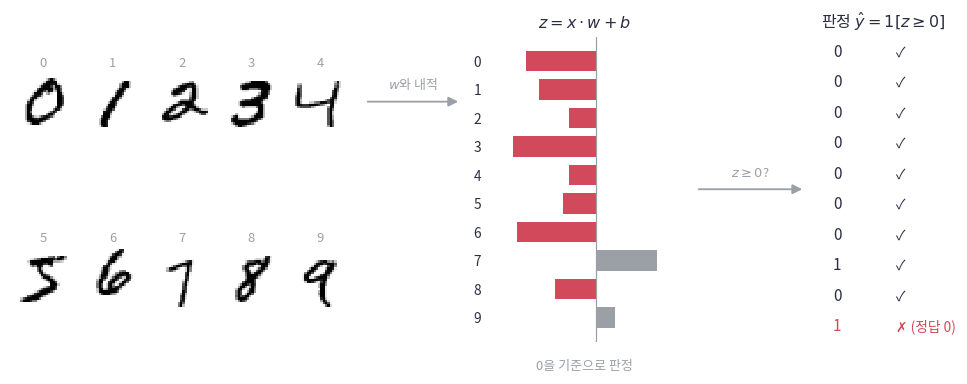

In [4]:
plot_perceptron_decision(mnist_examples, scores_e, decisions_e, targets_e, mnist_labels)

🔍 **확인** · 점수가 0 이상인 이미지만 1(7이다)로 판정합니다. 7은 맞혔지만 9도 점수가 양수라 7이라고 잘못 판정했습니다.
퍼셉트론 학습 규칙은 이렇게 **틀린 표본만** 골라 그 입력을 가중치에 더하거나 뺍니다. 9의 이미지를 $w$에서 빼면 9의 점수가 내려갑니다.
아래 구현에서 이 규칙을 AND 문제에 적용해 검산합니다.

In [5]:
def perceptron_predict(X, w, b):
    """퍼셉트론 판정: ŷ = 1[x·w + b ≥ 0]. X: (N, D), w: (D,), b: 숫자 → (N,) 0/1 정수."""
    return (X @ w + b >= 0).astype(int)


def fit_perceptron(X, y, learning_rate=1.0, epochs=30):
    """퍼셉트론 학습 규칙: 틀린 표본만 w += η(y − ŷ)x, b += η(y − ŷ). 한 에폭에 틀린 것이 없으면 멈춥니다.
    X: (N, D), y: (N,) 0/1 → (w: (D,), b: 숫자, 에폭별 오분류 수 목록)."""
    w, b = np.zeros(X.shape[1]), 0.0                   # 0에서 시작
    mistakes_per_epoch = []
    for epoch in range(epochs):
        mistakes = 0
        for x, target in zip(X, y):                    # 표본 하나씩
            prediction = int(x @ w + b >= 0)           # 지금 판정 ŷ
            error = target - prediction                # y − ŷ: 0(맞음), +1(1을 놓침), −1(0을 1로)
            if error != 0:                             # 틀린 표본만 고칩니다
                w += learning_rate * error * x         # 점수를 정답 쪽으로: +1이면 x를 더해 점수 ↑, −1이면 빼서 ↓
                b += learning_rate * error
                mistakes += 1
        mistakes_per_epoch.append(mistakes)
        if mistakes == 0:                              # 모두 맞히면 종료
            break
    return w, b, mistakes_per_epoch

In [6]:
# 쓰는 것: corners, y_and, mnist_Xe, template_7 (📎 데이터 셀) · decisions_e (1절 그림 셀)
hand_w, hand_b = np.array([1., 1.]), -1.5              # 손으로 정한 AND 퍼셉트론
np.testing.assert_array_equal(perceptron_predict(corners, hand_w, hand_b), y_and)     # 검산: 손으로 정한 w, b가 AND를 맞힘
w_and, b_and, mistakes = fit_perceptron(corners, y_and)
np.testing.assert_array_equal(perceptron_predict(corners, w_and, b_and), y_and)       # 검산: 학습한 w, b도 AND를 맞힘
np.testing.assert_array_equal(perceptron_predict(mnist_Xe, template_7, 0.0), decisions_e)   # 검산: 위 그림의 판정과 같은 함수
print("손으로 정한 점수", corners @ hand_w + hand_b)
print("학습한 w", w_and, "b", b_and, "· 에폭별 오분류", mistakes)

손으로 정한 점수 [-1.5 -0.5 -0.5  0.5]
학습한 w [2. 1.] b -3.0 · 에폭별 오분류 [2, 3, 3, 2, 1, 0]


🔍 **확인** · 위 업데이트는 오분류 여부를 사용하는 퍼셉트론 규칙입니다.
$y-\hat y=1$이면 정답 1을 놓쳤으므로 그 입력의 점수를 높이고, −1이면 낮춥니다.
한 표본을 수정한 직후 같은 입력의 점수 변화는 $\eta(y-\hat y)(\|x\|^2+1)$입니다.
계단함수는 0을 제외하면 도함수가 0이고 0에서는 미분 불가능합니다. 뒤의 신경망 학습에서는 logit과 미분 가능한 손실을 연결합니다.

## 🔑 2. XOR: 선형 분리의 한계를 수식으로 확인합니다

**이 절에서 가져갈 것:** 직선 하나로 나눌 수 없는 데이터가 있고, 선형 계산을 여러 번 겹쳐도 결국 직선 하나입니다. 그래서 비선형이 필요합니다.

"붉기와 무게 중 **하나만** 1이면 1"이 XOR입니다. 라벨은 `[0,1,1,0]`입니다.

> **용어**
>
> - **선형 분리 가능(linearly separable)**: 직선(고차원에서는 평면) 하나로 두 클래스를 완전히 나눌 수 있는 것. AND는 가능, XOR은 불가능.
> - **XOR(exclusive or)**: 두 입력이 다를 때만 1. 층을 쌓아야 하는 이유를 보여 주는 가장 작은 예제.

같은 퍼셉트론으로 정확히 분류하려면 다음 네 조건이 필요합니다.

$$b<0,\quad w_1+b\ge0,\quad w_0+b\ge0,\quad w_0+w_1+b<0.$$

가운데 두 조건을 더하면 $w_0+w_1+b\ge-b>0$이 되어 마지막 조건과 모순입니다.
따라서 학습 횟수와 별개로 이 선형 판정 구조는 네 점을 모두 분류할 수 없습니다.

선형 계산만 여러 번 합성해도 같은 문제가 남습니다.

$$(XW_1+b_1)W_2+b_2=X(W_1W_2)+(b_1W_2+b_2).$$


In [7]:
# 쓰는 것: corners, y_and (📎 데이터 셀). 그림용: AND의 결정 경계 직선
line_x = np.linspace(-0.4, 1.4, 50)                     # (50,): 직선을 그릴 x0 좌표
line_y = 1.5 - line_x                                   # (50,): x0 + x1 = 1.5, 곧 z = x0 + x1 − 1.5 = 0인 자리
np.testing.assert_array_equal((corners @ np.array([1., 1.]) - 1.5 >= 0).astype(int), y_and)   # 검산: 이 직선 위쪽만 1 = AND
print("검산 통과: 직선 x0 + x1 = 1.5의 위쪽이 정확히 AND의 1입니다")

검산 통과: 직선 x0 + x1 = 1.5의 위쪽이 정확히 AND의 1입니다


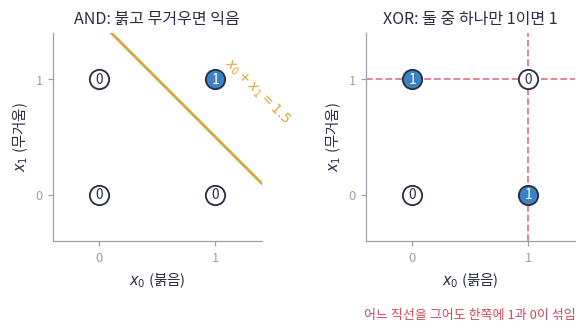

In [8]:
plot_separability(corners, y_and, Y_xor, line_x, line_y)

🔍 **확인** · 왼쪽 AND는 금색 직선 $x_0+x_1=1.5$ 위쪽에만 1이 있어 직선 하나로 나뉩니다.
오른쪽 XOR은 1이 대각선 두 귀퉁이에 있어, 어느 직선을 그어도 한쪽에 1과 0이 섞입니다. 아래에서는 선형층 두 개를 겹쳐도 직선 하나와 같다는 것을 숫자로 확인합니다.

In [9]:
# 쓰는 것: corners (📎 데이터 셀)
rng = np.random.default_rng(303)
W1 = rng.normal(size=(2, 3))                            # (2, 3): 첫 선형층. 입력 2 → 3
b1 = rng.normal(size=3)                                 # (3,)
W2 = rng.normal(size=(3, 1))                            # (3, 1): 둘째 선형층. 3 → 1
b2 = rng.normal(size=1)                                 # (1,)
two_affine_layers = (corners @ W1 + b1) @ W2 + b2       # (4, 1): 선형층 두 개를 차례로
collapsed_affine = corners @ (W1 @ W2) + (b1 @ W2 + b2) # (4, 1): 미리 곱해 둔 선형층 하나. 위 수식의 오른쪽
np.testing.assert_allclose(two_affine_layers, collapsed_affine)   # 검산: 두 결과가 같음
print("선형층 2개와 합친 선형층의 최대 차이:", np.max(np.abs(two_affine_layers - collapsed_affine)))

선형층 2개와 합친 선형층의 최대 차이: 2.220446049250313e-16


🔍 **확인** · 선형층 두 개를 거친 결과와 미리 곱해 둔 선형층 하나의 결과가 같습니다. 층을 아무리 쌓아도 직선 하나이므로 XOR은 그대로 못 풉니다.

## 🔑 3. 활성화: 표현을 바꾸고 그 변화율도 계산합니다

**이 절에서 가져갈 것:** 층 사이에 원소별 비선형 함수(활성화)를 넣으면 겹친 계산이 직선 하나로 줄어들지 않습니다. 역전파에서는 그 함수의 도함수를 곱합니다.

> **용어**
>
> - **활성화 함수(activation)**: 배열의 각 원소에 따로 적용하는 비선형 함수. 모양은 그대로, 값만 바뀝니다.
> - **은닉층(hidden layer)·은닉 유닛**: 입력과 출력 사이의 중간 계산. 유닛 하나가 00번의 뉴런 하나입니다.
> - **표현(representation)**: 은닉층이 만든 새 좌표. 원래 입력에서 안 나뉘던 점들이 새 좌표에서는 나뉠 수 있습니다.

| 함수 | forward | 원소별 미분 |
|---|---|---|
| sigmoid | $1/(1+e^{-z})$ | $p(1-p)$ |
| tanh | $(e^z-e^{-z})/(e^z+e^{-z})$ | $1-\tanh^2z$ |
| ReLU | $\max(0,z)$ | $z>0$이면 1, $z<0$이면 0 |

ReLU의 0에서는 미분이 정의되지 않습니다. 여기서는 backward를 0으로 정하고, 중심차분 검사는 0에서 떨어진 입력을 씁니다.
은닉층에는 tanh를 사용해 처음의 역전파를 매끄러운 함수에서 확인하겠습니다.
📎 02의 sigmoid 미분에서 tanh 미분도 연결할 수 있습니다. $t=\tanh z=2\sigma(2z)-1$이므로 $t'=4\sigma(2z)(1-\sigma(2z))=1-t^2$입니다.

> **코드**
>
> - `(z_axis > 0).astype(float)`: True/False를 1.0/0.0으로. 표의 ReLU 도함수 "z > 0이면 1, 아니면 0"입니다.
> - `{"tanh": …, "relu": …, "sigmoid": …}`: 이름으로 배열을 찾는 사전(dict). 그림 함수와 검산이 같은 이름으로 꺼내 씁니다.
> - `np.where(z >= 0, a, b)`: 자리마다 조건이 참이면 a, 거짓이면 b를 고릅니다. sigmoid를 두 식으로 나눠 쓰는 데 씁니다(02번 7절).

In [10]:
z_axis = np.linspace(-5, 5, 301)                       # (301,): 그림용 z 좌표
sig = 1 / (1 + np.exp(-z_axis))                        # (301,): sigmoid
curve_values = {"tanh": np.tanh(z_axis), "relu": np.maximum(z_axis, 0), "sigmoid": sig}                      # 표의 forward 열
curve_derivatives = {"tanh": 1 - np.tanh(z_axis) ** 2, "relu": (z_axis > 0).astype(float), "sigmoid": sig * (1 - sig)}   # 표의 미분 열

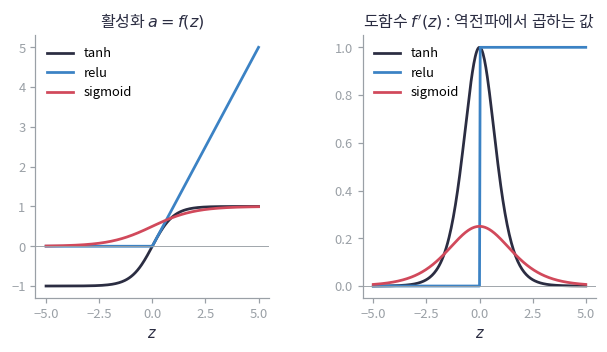

In [11]:
plot_activation_curves(z_axis, curve_values, curve_derivatives)

🔍 **확인** · 왼쪽이 활성화의 출력, 오른쪽이 역전파에서 곱하는 도함수입니다.
sigmoid와 tanh의 양 끝에서는 도함수가 작습니다. 여러 층에서 작은 값을 계속 곱하면 앞쪽 기울기가 작아질 수 있습니다.
ReLU는 양수 구간의 도함수가 1이지만 음수 구간에서는 0입니다. 활성화의 출력뿐 아니라 backward에서 곱하는 값도 함께 봅니다.

In [12]:
def sigmoid(z):
    """σ(z) = 1/(1 + e^−z)를 큰 |z|에서도 넘치지 않게 (02번 7절). z: 어떤 모양 → 같은 모양."""
    t = np.exp(-np.abs(z))                              # e^−|z| ≤ 1
    return np.where(z >= 0, 1 / (1+t), t / (1+t))       # z ≥ 0: 원래 식, z < 0: 분자·분모에 e^z를 곱한 같은 식


def activation(z, kind="tanh"):
    """활성화 함수 forward (표의 가운데 열). z: 어떤 모양, kind: "tanh" | "relu" | "sigmoid" → 같은 모양."""
    if kind == "tanh":
        return np.tanh(z)
    if kind == "relu":
        return np.maximum(z, 0)
    if kind == "sigmoid":
        return sigmoid(z)
    raise ValueError("알 수 없는 활성화")


def activation_derivative(z, kind="tanh"):
    """활성화 함수의 원소별 도함수 (표의 오른쪽 열). backward에서 곱하는 값. z: 어떤 모양 → 같은 모양."""
    if kind == "tanh":
        return 1 - np.tanh(z)**2
    if kind == "relu":
        return (z > 0).astype(float)                    # 0에서는 0으로 정함
    if kind == "sigmoid":
        p = sigmoid(z)
        return p * (1-p)
    raise ValueError("알 수 없는 활성화")

In [13]:
# 쓰는 것: z_axis, curve_values, curve_derivatives (3절 그림 계산 셀)
activation_errors = {}
probe = np.array([-1.3, -0.2, 0.4, 1.7])                         # (4,): 검사 입력. 0에서 떨어진 값 (ReLU의 꺾이는 점을 피함)
for kind in ("tanh", "relu", "sigmoid"):
    def forward(z, kind=kind):
        """검사기용: 활성화 출력. kind=kind는 반복 변수의 그때 값을 붙잡아 두는 것."""
        return activation(z, kind)

    def backward(dout, z, kind=kind):
        """검사기용: 상류 기울기 × 손으로 유도한 원소별 도함수."""
        return dout * activation_derivative(z, kind)

    activation_errors[kind] = check_function(forward, backward, probe, verbose=True, name=kind)   # 중심차분과 대조
np.testing.assert_allclose(activation_derivative(np.array([0.]), "relu"), 0)        # 검산: ReLU의 0에서 backward는 0으로 정함
for name in activation_errors:
    np.testing.assert_allclose(activation(z_axis, name), curve_values[name])                 # 검산: 위 그림의 곡선과 같은 함수
    np.testing.assert_allclose(activation_derivative(z_axis, name), curve_derivatives[name])  # 검산: 도함수 곡선도 같음

[gradcheck] tanh
  ok   dx  rel_err = 5.348e-11
[gradcheck] relu
  ok   dx  rel_err = 5.062e-11
[gradcheck] sigmoid
  ok   dx  rel_err = 1.911e-10


### 🔍 손으로 만든 은닉층으로 XOR 풀기

$s=x_0+x_1$, $h_0=\operatorname{ReLU}(s)$, $h_1=\operatorname{ReLU}(s-1)$로 놓습니다.
네 입력에서 $h_0-2h_1$은 `0,1,1,0`이 됩니다.
마지막 logit을 $z=10(h_0-2h_1-0.5)$로 두면 부호로 XOR을 구분할 수 있습니다.

In [14]:
# 쓰는 것: corners, Y_xor (📎 데이터 셀) · activation (3절)
hand_W1 = np.array([[1., 1.], [1., 1.]])                 # (2, 2): 두 은닉 유닛 모두 s = x0 + x1을 계산
hand_b1 = np.array([0., -1.])                           # (2,): h0 = ReLU(s), h1 = ReLU(s − 1)
hand_hidden = activation(corners @ hand_W1 + hand_b1, "relu")   # (4, 2): 네 입력의 은닉 표현
hand_logits = hand_hidden @ np.array([[10.], [-20.]]) - 5       # (4, 1): z = 10(h0 − 2h1 − 0.5)
np.testing.assert_allclose(hand_hidden, [[0,0], [1,0], [1,0], [2,1]])   # 검산: 손계산 은닉 표현
np.testing.assert_array_equal((hand_logits >= 0).astype(float), Y_xor)  # 검산: 부호가 XOR과 같음
print("은닉 표현:\n", hand_hidden)
print("최종 logit:", hand_logits.ravel())

은닉 표현:
 [[0. 0.]
 [1. 0.]
 [1. 0.]
 [2. 1.]]
최종 logit: [-5.  5.  5. -5.]


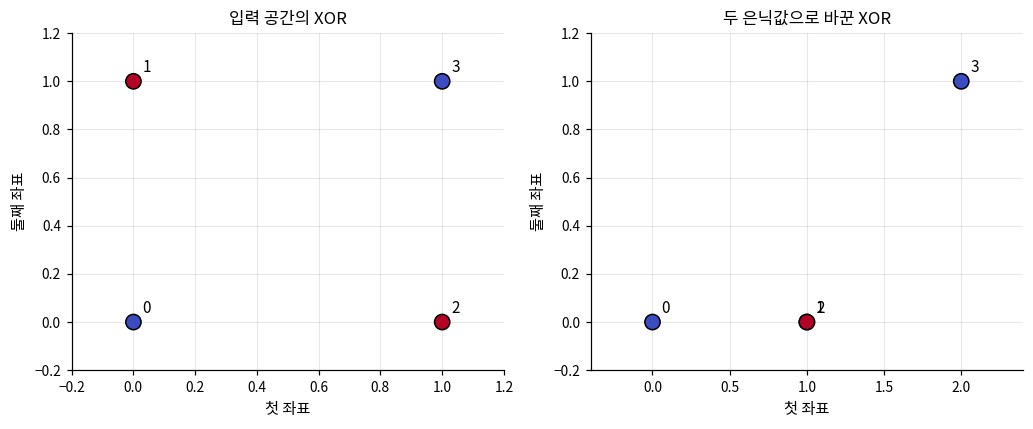

In [15]:
plot_representation(corners, hand_hidden, Y_xor)

🔍 **확인** · 입력에서 한 직선으로 나눌 수 없었던 점들이 은닉 표현에서는 선형 판정 가능한 위치로 바뀝니다.
1번과 2번 점은 같은 은닉 좌표에 겹칩니다. 이 예제는 가중치를 손으로 정했고, 이제 손실에서 같은 종류의 구조를 학습시키겠습니다.

## 🔑 4. MLP forward: 층마다 같은 규칙을 적용합니다

**이 절에서 가져갈 것:** forward는 층마다 `Z = A @ W + b`, `A = tanh(Z)`의 반복입니다. 마지막 층만 활성화 없이 logit을 내고, A와 Z는 캐시에 남깁니다.

> **용어**
>
> - **MLP(multilayer perceptron, 다층 퍼셉트론)**: 선형층과 활성화를 번갈아 쌓은 신경망.
> - **층(layer)** $\ell$: 선형 계산 한 번 + 활성화 한 번. `sizes=[784, 32, 1]`은 입력 784, 은닉 32, 출력 1.
> - **캐시(cache)**: forward에서 계산한 $A_{\ell-1}$과 $Z_\ell$을 backward에서 다시 쓰려고 보관한 것.

$$A_0=X,\quad Z_\ell=A_{\ell-1}W_\ell+b_\ell,\quad
A_\ell=\tanh(Z_\ell)\ (\ell<L),\quad Z_L=\text{logits}.$$

| 이름 | 일반 shape | 2 → 4 → 1 예제 |
|---|---|---|
| $A_{\ell-1}$ | `(N, d_in)` | 첫 층 입력 `(N,2)` |
| $W_\ell,b_\ell$ | `(d_in,d_out)`, `(d_out,)` | `(2,4)`, `(4,)` |
| $Z_\ell,A_\ell$ | `(N,d_out)` | 은닉값 `(N,4)` |
| 최종 logit | `(N,1)` | 이진 분류의 점수 |

📎 파라미터는 `[{'W': ..., 'b': ...}, ...]` 형태의 목록입니다. 이웃한 크기 쌍으로 가중치를 만듭니다.
초기 가중치는 서로 다른 난수로 정합니다. 모든 은닉 유닛을 같은 값으로 시작하면 같은 역할에서 벗어나지 못할 수 있습니다.
여기서는 tanh를 위해 표준편차 $\sqrt{2/(d_{in}+d_{out})}$인 **Glorot 초기화**를 사용하고, 04에서 크기의 영향을 직접 실험합니다.

아래는 7 이미지 한 장이 학습 전 MLP `[784, 32, 1]`을 지나는 모습입니다.

> **코드**
>
> - `mnist_Xe[7:8]`: 슬라이스로 행 하나를 고르면 `(1, 784)` 2차원이 유지됩니다. `mnist_Xe[7]`은 `(784,)`입니다.
> - `zip(sizes[:-1], sizes[1:])`: `[784, 32, 1]`에서 이웃한 쌍 (784, 32), (32, 1)을 냅니다. 쌍마다 층 하나입니다.
> - `[{"W": …, "b": …} for din, dout in zip(…)]`: 쌍마다 사전 하나를 만들어 목록으로 모읍니다(컴프리헨션). 층 ℓ의 가중치는 `parameters[ℓ]["W"]`입니다.
> - `for layer_index, layer in enumerate(parameters)`: 번호와 원소를 함께 돕니다. 마지막 층인지 판단하는 데 번호를 씁니다.
> - `caches[0][1]`: 캐시는 층마다 `(A_prev, Z)` 쌍의 목록이라, `[0]`은 첫 층, `[1]`은 그중 Z입니다.

In [16]:
# 쓰는 것: mnist_Xe (📎 데이터 셀)
rng_init = np.random.default_rng(0)
sizes = [784, 32, 1]                                 # 입력 784 → 은닉 32 → 출력 1
W1_r = rng_init.normal(size=(784, 32)) * np.sqrt(2 / (784 + 32))   # (784, 32): Glorot 초기화 (표준편차 √(2/(d_in + d_out)))
b1_r = np.zeros(32)                                  # (32,)
W2_r = rng_init.normal(size=(32, 1)) * np.sqrt(2 / (32 + 1))       # (32, 1)
b2_r = np.zeros(1)                                   # (1,)
x7 = mnist_Xe[7:8]                                   # (1, 784): 예시 7 한 장
Z1_r = x7 @ W1_r + b1_r                              # (1, 32): 첫 층의 선형 계산
A1_r = np.tanh(Z1_r)                                 # (1, 32): 은닉 활성
z_r = A1_r @ W2_r + b2_r                             # (1, 1): logit
p_r = 1 / (1 + np.exp(-z_r))                         # (1, 1): 7일 확률
print("은닉 활성 범위", A1_r.min().round(2), A1_r.max().round(2), "· logit", z_r.ravel().round(3), "· 확률", p_r.ravel().round(3))

은닉 활성 범위 -0.63 0.66 · logit [0.311] · 확률 [0.577]


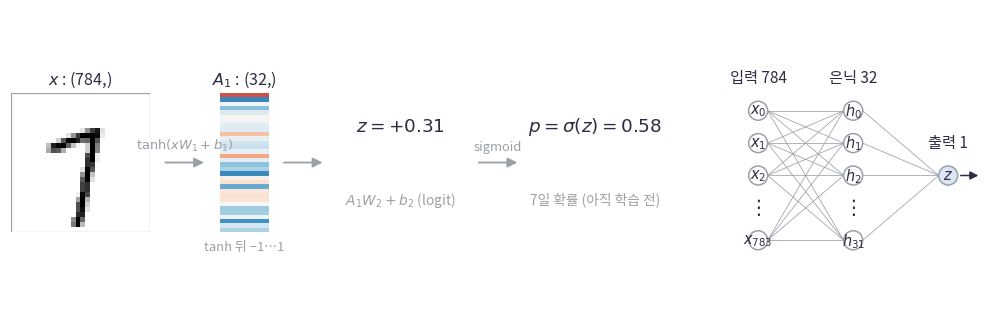

In [17]:
plot_mlp_forward_flow(mnist_examples[7], A1_r.ravel(), float(z_r[0, 0]), float(p_r[0, 0]), sizes)

🔍 **확인** · 784개 화소가 첫 층에서 32개 은닉 활성으로, 다시 logit 하나로 줄어듭니다. 가운데 띠가 $A_1$이고 tanh를 거쳐 −1과 1 사이입니다.
아직 학습 전이라 확률은 0.5 근처입니다. 오른쪽 도식의 선 하나가 $W_1$ 또는 $W_2$의 원소 하나이고, 선이 $784\times32+32$개입니다.

In [18]:
def init_mlp(sizes, seed=0):
    """층마다 Glorot 초기화한 파라미터 목록. sizes: [d_0, d_1, …, d_L] → [{"W": (d_0, d_1), "b": (d_1,)}, …]."""
    rng = np.random.default_rng(seed)
    return [{"W": rng.normal(size=(din, dout)) * np.sqrt(2 / (din + dout)),   # 표준편차 √(2/(d_in + d_out))인 난수
             "b": np.zeros(dout)}                                             # 편향은 0
            for din, dout in zip(sizes[:-1], sizes[1:])]                      # 이웃한 크기 쌍마다 층 하나


def mlp_forward(X, parameters, hidden_activation="tanh"):
    """MLP forward: 층마다 Z = A @ W + b, A = activation(Z). 마지막 층은 활성화 없이 logit.
    X: (N, d_0), parameters: init_mlp의 목록 → (logits: (N, d_L), caches: 층마다 (A_prev, Z) 쌍의 목록)."""
    # 쓰는 것: activation (3절)
    A = X                                                    # A_0 = X
    caches = []
    for layer_index, layer in enumerate(parameters):
        Z = A @ layer["W"] + layer["b"]                      # (N, d_out): 선형 계산
        caches.append((A, Z))                                # backward에 쓸 입력과 활성화 전 값
        last = layer_index == len(parameters) - 1
        A = Z if last else activation(Z, hidden_activation)  # 마지막 층은 logit 그대로
    return A, caches

In [19]:
small_parameters = [                                     # 2 → 2 → 1 손계산 예제
    {"W": np.array([[1., -1.], [0.5, 2.]]), "b": np.array([0.1, -0.2])},    # 첫 층 (2, 2), (2,)
    {"W": np.array([[0.3], [-0.4]]), "b": np.array([0.2])},                 # 둘째 층 (2, 1), (1,)
]
small_X = np.array([[1., 2.]])                           # (1, 2): 입력 하나
small_logits, small_cache = mlp_forward(small_X, small_parameters)
# 첫 층은 [1*1+2*0.5+0.1, 1*(-1)+2*2-0.2] = [2.1,2.8]
manual_hidden = np.tanh(np.array([2.1, 2.8]))            # (2,): 손계산 은닉 활성
manual_logit = 0.3 * manual_hidden[0] - 0.4 * manual_hidden[1] + 0.2   # 손계산 logit
np.testing.assert_allclose(small_cache[0][1], [[2.1, 2.8]])   # 검산: 첫 층의 Z = 손계산
np.testing.assert_allclose(small_logits, [[manual_logit]])   # 검산: 최종 logit = 손계산
print("첫 층 Z", small_cache[0][1], "· 은닉 A", manual_hidden, "· 최종 logit", small_logits)
for layer, (A, Z) in zip(small_parameters, small_cache):     # 층마다 파라미터와 캐시를 짝지어 모양 확인
    print("A", A.shape, "W", layer["W"].shape, "b", layer["b"].shape, "Z", Z.shape)

첫 층 Z [[2.1 2.8]] · 은닉 A [0.97045 0.99263] · 최종 logit [[0.09408]]
A (1, 2) W (2, 2) b (2,) Z (1, 2)
A (1, 2) W (2, 1) b (1,) Z (1, 1)


🔍 **확인** · 캐시에는 층마다 입력 A와 활성화 전 값 Z가 남습니다. 파라미터는 forward·backward 계산이 끝난 뒤 갱신합니다.
중간에 W를 바꾸면 다른 파라미터에서 계산한 기울기를 섞게 됩니다.

## 🔑 5. backward: 손실에서 출발해 같은 길을 거꾸로 갑니다

**이 절에서 가져갈 것:** 층마다 세 줄입니다. `dW = A_prev.T @ dZ`, `db = dZ.sum(0)`, `dA_prev = dZ @ W.T`. 앞이 은닉층이면 활성화 도함수를 원소별로 곱해 `dZ_prev`를 만듭니다.

BCE의 최종 logit 기울기는 $D_L=(\sigma(Z_L)-Y)/N$입니다(02번). 여기서는 출력이 하나입니다.

> **용어** · **원소별 곱** $\odot$: 같은 모양의 두 배열을 같은 자리끼리 곱하는 것. 코드의 `*`. 행렬곱 `@`와 구분합니다.

$$\frac{\partial J}{\partial W_\ell}=A_{\ell-1}^\top D_\ell,\quad
\frac{\partial J}{\partial b_\ell}=\sum_n D_{\ell,n},\quad
\frac{\partial J}{\partial A_{\ell-1}}=D_\ell W_\ell^\top.$$

앞이 은닉층이면 $D_{\ell-1}=(D_\ell W_\ell^\top)\odot(1-\tanh^2 Z_{\ell-1})$입니다.
입력 X까지 기울기를 전달하면 01의 affine backward와 연결됩니다.

$\partial J/\partial W_{dk}=\sum_n A_{nd}D_{nk}$입니다. 모든 샘플에서 **같은 W를 공유**하므로 사용된 자리의 기여를 합합니다.
📎 같은 파라미터가 다른 위치나 시간에 반복 사용될 때도 이 원리가 CNN·RNN으로 이어집니다.

아래는 4절의 7 이미지에서 정답 1을 향해 역전파했을 때, 오차가 어느 선을 따라 어떻게 퍼지는지입니다.

> **코드**
>
> - `range(len(parameters) - 1, -1, -1)`: 마지막 층 번호부터 0까지 거꾸로 셉니다. backward는 출력층에서 시작하기 때문입니다.
> - `[None] * len(parameters)`: 층 수만큼 빈 자리를 만든 목록. 거꾸로 돌면서 `gradients[index]`에 채웁니다.
> - `backward_fn=mlp_backward`: 기본 인자로 함수를 넘깁니다. 검산 때 다른 backward를 끼워 넣을 수 있게 한 것입니다.
> - `x7.T @ dZ1_r`: `(784, 1) @ (1, 32)` = `(784, 32)`. 열 j는 x7 전체에 숫자 하나 `dZ1[j]`를 곱한 것입니다.

In [20]:
# 쓰는 것: p_r, A1_r, W2_r, x7 (4절 forward 흐름 셀)
dz_r = p_r - 1.0                                     # (1, 1): 정답 1에 대한 logit 기울기 p − y (N = 1)
dW2_r = A1_r.T @ dz_r                                # (32, 1): 둘째 층 dW = A_1ᵀ D_2
dA1_r = dz_r @ W2_r.T                                # (1, 32): 은닉 활성의 기울기 D_2 W_2ᵀ
dZ1_r = dA1_r * (1 - A1_r ** 2)                      # (1, 32): tanh 도함수 1 − A²을 원소별로 곱함 → D_1
dW1_r = x7.T @ dZ1_r                                 # (784, 32): 첫 층 dW = A_0ᵀ D_1. 열 j = x7 × dZ1[j]
picked = [0, 1, 2]                                   # 그림에 보일 은닉 유닛 번호
np.testing.assert_allclose(dW1_r[:, 0], x7.ravel() * dZ1_r[0, 0])   # 검산: 열 0 = 입력 이미지 × 그 유닛에 도착한 오차
print("dz", dz_r.ravel().round(3), "· dZ1[:3]", dZ1_r.ravel()[:3].round(3))

dz [-0.423] · dZ1[:3] [-0.055 -0.079 -0.242]


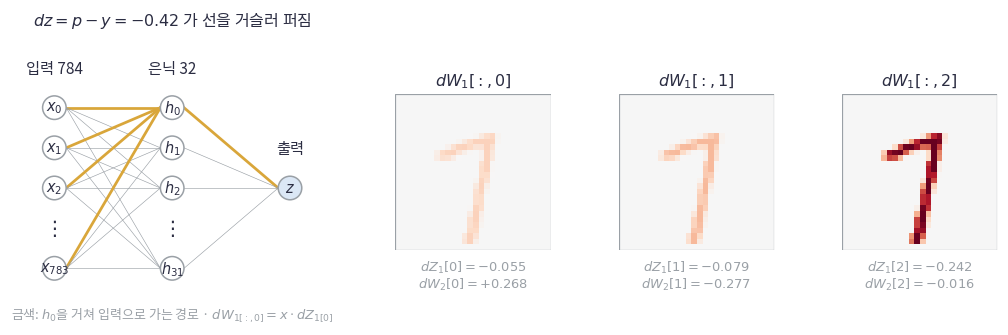

In [21]:
plot_backward_flow(sizes, picked, float(dz_r[0, 0]), dZ1_r.ravel()[picked],
                   [dW1_r[:, j].reshape(28, 28) for j in picked], dW2_r.ravel()[picked])

🔍 **확인** · 출력의 오차 $dz=p-y$가 $W_2$의 선을 타고 은닉 유닛 32개로 나뉘고, tanh의 도함수를 곱해 $dZ_1$이 됩니다.
오른쪽 세 판은 은닉 유닛 0, 1, 2의 가중치 기울기 $dW_1[:, j]$입니다. 셋 다 **입력 이미지 7의 모양**이고, 크기와 부호만 $dZ_1[j]$로 다릅니다.
`A_prev.T @ dZ`가 "입력 × 그 유닛에 도착한 오차"라는 뜻이기 때문입니다. 01번의 기울기 이미지가 층마다 하나씩 생기는 셈입니다.

In [22]:
def bce_with_logits(logits, targets):
    """평균 BCE와 logit 기울기 (02번 7절): J = mean(log(1 + e^z) − yz), dZ = (σ(z) − y)/M.
    logits, targets: 같은 모양 (N, 1) → (J: 숫자, dZ: (N, 1))."""
    # 쓰는 것: sigmoid (3절)
    assert logits.shape == targets.shape, "logit과 정답은 같은 모양이어야 합니다"
    loss = np.mean(np.logaddexp(0, logits) - targets * logits)
    return float(loss), (sigmoid(logits) - targets) / targets.size

In [23]:
def mlp_backward(dlogits, parameters, caches, hidden_activation="tanh"):
    """MLP backward: 출력층부터 거꾸로 층마다 dW = A_prevᵀ D, db = Σ_n D, dA_prev = D Wᵀ, 앞이 은닉층이면 D_prev = dA_prev ⊙ f'(Z_prev).
    dlogits: (N, d_L) 최종 logit 기울기, parameters·caches: forward의 것 → (dX: (N, d_0), gradients: 층마다 {"W", "b"})."""
    # 쓰는 것: activation_derivative (3절)
    gradients = [None] * len(parameters)
    dZ = dlogits                                            # D_L
    for index in range(len(parameters) - 1, -1, -1):       # 마지막 층부터 거꾸로
        A_previous, Z = caches[index]
        W = parameters[index]["W"]
        gradients[index] = {"W": A_previous.T @ dZ, "b": dZ.sum(axis=0)}   # ∂J/∂W = A_{ℓ−1}ᵀ D_ℓ, ∂J/∂b = Σ_n D_ℓ
        dA_previous = dZ @ W.T                              # (N, d_in): ∂J/∂A_{ℓ−1} = D_ℓ W_ℓᵀ
        if index == 0:
            dX = dA_previous                                # 첫 층 앞은 입력 X
        else:
            previous_Z = caches[index - 1][1]               # 앞 층의 활성화 전 값
            dZ = dA_previous * activation_derivative(previous_Z, hidden_activation)   # D_{ℓ−1} = dA ⊙ f'(Z_{ℓ−1})
    return dX, gradients

In [24]:
def mlp_loss_and_gradients(X, Y, parameters, l2=0.0, backward_fn=mlp_backward):
    """forward → BCE → backward를 한 번에. l2 > 0이면 목적에 (λ/2) Σ‖W‖²을 더하고 dW에 λW를 더합니다(8절).
    X: (N, d_0), Y: (N, 1) → (목적 J: 숫자, dX: (N, d_0), gradients: 층마다 {"W", "b"})."""
    # 쓰는 것: mlp_forward (4절)
    logits, caches = mlp_forward(X, parameters)
    data_loss, dlogits = bce_with_logits(logits, Y)         # 평균 BCE와 D_L
    dX, gradients = backward_fn(dlogits, parameters, caches)
    penalty = 0.0
    for layer, gradient in zip(parameters, gradients):      # 층마다 L2 페널티와 그 미분
        penalty += 0.5 * l2 * np.sum(layer["W"]**2)         # (λ/2)‖W‖²
        gradient["W"] += l2 * layer["W"]                    # dW += λW. l2 = 0이면 아무 일도 없음
    return data_loss + penalty, dX, gradients

🔍 **확인** · `l2=0`에서는 위의 BCE만 사용합니다. `l2`가 양수인 경우의 목적과 미분은 8절에서 설명하고 검산합니다.
`gradients`는 파라미터와 같은 순서·같은 키·같은 shape입니다. 업데이트는 이 기울기를 계산한 다음 별도 단계에서 수행합니다.

## 🔍 6. 모든 가중치·편향·입력의 기울기를 검산합니다

손으로 유도한 backward와, 파라미터 원소를 $\pm\epsilon$ 바꾸어 forward만 재계산하는 중심차분을 대조합니다.
`check_function`의 forward는 스칼라 손실을 반환하고, `dout=1`을 전달하므로 같은 손실을 직접 미분합니다.
`index`와 `key`로 검사할 배열 하나를 선택하고 나머지 파라미터는 그대로 둡니다.

> **코드**
>
> - `[dict(item) for item in parameters]`: 층마다 사전을 복사해 새 목록을 만듭니다. 원본 파라미터는 두고 한 자리만 바꾸기 위해서입니다.
> - `def changed(value, index=index, key=key)`: 반복문 안에서 함수를 만들 때 반복 변수의 **그때 값**을 기본 인자로 붙잡아 둡니다(01번 5절).
> - `f"{key}{index+1}"`: 이름표 "W1", "b1", "W2", …. 층 번호는 1부터 셉니다.

In [25]:
def check_mlp_gradients(X, Y, parameters, l2=0.0, backward_fn=mlp_backward):
    """모든 층의 W·b와 입력 X의 기울기를 중심차분과 대조합니다. → {"W1", "b1", …, "X"}: 상대오차."""
    # 쓰는 것: mlp_loss_and_gradients (5절)
    errors = {}
    for index, layer in enumerate(parameters):
        for key in ("W", "b"):
            def changed(value, index=index, key=key):
                """parameters를 복사한 뒤 (index, key) 자리만 value로 바꾼 목록."""
                copy = [dict(item) for item in parameters]
                copy[index][key] = value
                return copy

            def forward(value):
                """검사기용: 그 자리만 바꿨을 때의 목적 J."""
                return np.array(mlp_loss_and_gradients(X, Y, changed(value), l2, backward_fn)[0])

            def backward(dout, value, index=index, key=key):
                """검사기용: 손으로 유도한 그 자리의 기울기 × 상류 기울기 dout."""
                grads = mlp_loss_and_gradients(X, Y, changed(value), l2, backward_fn)[2]
                return dout * grads[index][key]

            name = f"{key}{index+1}"
            errors[name] = check_function(forward, backward, layer[key], dout=np.array(1.),
                                           tol=2e-6, verbose=True, name=name)

    def forward_X(x):
        """검사기용: 입력 X만 바꿨을 때의 목적 J."""
        return np.array(mlp_loss_and_gradients(x, Y, parameters, l2, backward_fn)[0])

    def backward_X(dout, x):
        """검사기용: 손으로 유도한 dX × 상류 기울기 dout."""
        return dout * mlp_loss_and_gradients(x, Y, parameters, l2, backward_fn)[1]

    errors["X"] = check_function(forward_X, backward_X, X, dout=np.array(1.), tol=2e-6, verbose=True, name="X")
    return errors

In [26]:
# 쓰는 것: init_mlp (4절)
check_X = np.array([[-0.7, 0.2], [0.4, -0.8], [0.6, 0.5]])   # (3, 2): 작은 입력
check_Y = np.array([[0.], [1.], [0.]])                        # (3, 1): 라벨
check_parameters = init_mlp([2, 3, 2, 1], seed=17)            # 2 → 3 → 2 → 1: 층 세 개
network_errors = check_mlp_gradients(check_X, check_Y, check_parameters)
print("네트워크 최대 상대오차", max(network_errors.values()))

[gradcheck] W1
  ok   dx  rel_err = 1.399e-10
[gradcheck] b1
  ok   dx  rel_err = 1.478e-10
[gradcheck] W2
  ok   dx  rel_err = 2.647e-10
[gradcheck] b2
  ok   dx  rel_err = 2.829e-10
[gradcheck] W3
  ok   dx  rel_err = 3.370e-10
[gradcheck] b3
  ok   dx  rel_err = 6.154e-11
[gradcheck] X
  ok   dx  rel_err = 4.981e-10
네트워크 최대 상대오차 4.98115205884979e-10


<Axes: ylabel='상대오차'>

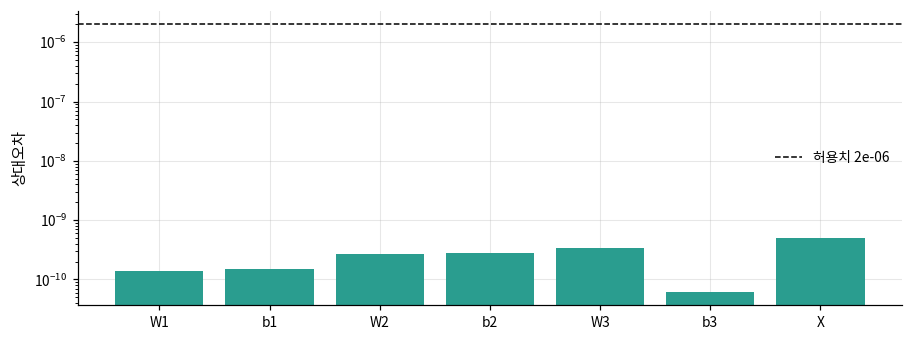

In [27]:
plot_gradcheck(network_errors, tol=2e-6)

🔍 **확인** · 샘플을 두 번 복제하면 평균 손실과 공유 파라미터의 기울기는 같습니다. 입력 각 복제본의 기울기는 평균의 분모 때문에 절반으로 줄어듭니다. 수치미분과는 다른 성질로 평균·합하는 축을 한 번 더 점검합니다.

In [28]:
# 쓰는 것: check_X, check_Y, check_parameters (6절 검산 셀) · mlp_loss_and_gradients (5절)
loss_one, dX_one, grad_one = mlp_loss_and_gradients(check_X, check_Y, check_parameters)
loss_twice, dX_twice, grad_twice = mlp_loss_and_gradients(
    np.concatenate([check_X, check_X]), np.concatenate([check_Y, check_Y]), check_parameters)   # 같은 배치를 두 번 이어 붙임 (N = 6)
np.testing.assert_allclose(loss_twice, loss_one)              # 검산: 평균 손실은 그대로
np.testing.assert_allclose(dX_twice[:len(check_X)], dX_one / 2)   # 검산: 복제본마다의 입력 기울기는 절반 (분모 N이 두 배)
for single, doubled in zip(grad_one, grad_twice):
    for key in ("W", "b"):
        np.testing.assert_allclose(single[key], doubled[key])   # 검산: 공유 파라미터의 기울기는 같음
print("배치 복제: 손실·공유 파라미터 기울기·입력 기울기 관계 통과")

배치 복제: 손실·공유 파라미터 기울기·입력 기울기 관계 통과


## 🔑 7. XOR을 실제로 학습시킵니다

**이 절에서 가져갈 것:** 같은 손실·같은 데이터·같은 갱신 규칙에서, 선형 모델은 XOR을 못 풀고 은닉층 하나를 넣은 MLP는 풉니다. 차이는 모델 구조뿐입니다.

두 모델 모두 같은 BCE, 같은 데이터, 같은 갱신 규칙을 사용합니다. `[2,1]`은 선형 logit이고 `[2,4,1]`은 tanh 은닉층을 가진 MLP입니다.
📎 `fit_mlp`는 시작 파라미터를 복사하므로 비교 실험끼리 배열을 공유하지 않습니다. 기록은 갱신 전 0회부터 갱신 후 마지막까지 저장합니다.

> **코드**
>
> - `[{key: value.copy() for key, value in layer.items()} for layer in initial_parameters]`: 층마다 W·b 배열을 복사해 새 파라미터 목록을 만듭니다. 바깥은 층에 대한 컴프리헨션, 안쪽은 사전 컴프리헨션입니다.
> - `history["train_bce"][-1]`: 목록의 마지막 원소. 학습이 끝난 뒤의 값입니다.

In [29]:
def fit_mlp(X, Y, initial_parameters, steps=2500, learning_rate=0.2, l2=0.0,
            validation=None):
    """MLP를 경사하강으로 steps번 갱신: 스텝마다 목적·기울기 → 층마다 W −= η dW, b −= η db.
    X: (N, d_0), Y: (N, 1), initial_parameters: init_mlp의 목록 → (parameters, history).
    history의 objective·train_bce는 갱신 전부터 steps+1개, validation을 주면 validation_bce도 기록합니다."""
    # 쓰는 것: mlp_loss_and_gradients, bce_with_logits (5절) · mlp_forward (4절)
    parameters = [{key: value.copy() for key, value in layer.items()} for layer in initial_parameters]   # 시작값을 복사해 원본 보존
    history = {"objective": [], "train_bce": [], "validation_bce": []}
    for step in range(steps + 1):                                       # 마지막 바퀴는 기록만
        objective, _, gradients = mlp_loss_and_gradients(X, Y, parameters, l2)   # 목적 (BCE + 페널티)과 기울기. dX는 안 씀
        logits, _ = mlp_forward(X, parameters)
        history["objective"].append(objective)
        history["train_bce"].append(bce_with_logits(logits, Y)[0])      # 페널티를 뺀 BCE만 따로 기록
        if validation is not None:                                      # 검증 데이터는 손실만 재고 갱신에는 안 씀
            val_X, val_Y = validation
            val_logits, _ = mlp_forward(val_X, parameters)
            history["validation_bce"].append(bce_with_logits(val_logits, val_Y)[0])
        if step == steps:
            break
        for layer, gradient in zip(parameters, gradients):              # 층마다 갱신
            layer["W"] -= learning_rate * gradient["W"]
            layer["b"] -= learning_rate * gradient["b"]
    return parameters, history

In [30]:
# 쓰는 것: corners, Y_xor (📎 데이터 셀) · init_mlp, mlp_forward (4절) · sigmoid (3절)
linear_model, linear_history = fit_mlp(corners, Y_xor, init_mlp([2, 1], seed=4))      # [2, 1]: 선형 logit
mlp_model, mlp_history = fit_mlp(corners, Y_xor, init_mlp([2, 4, 1], seed=4))         # [2, 4, 1]: tanh 은닉층 하나
linear_logits, _ = mlp_forward(corners, linear_model)
mlp_logits, mlp_caches = mlp_forward(corners, mlp_model)
mlp_accuracy = np.mean((mlp_logits >= 0) == Y_xor)                                     # logit 부호로 판정한 정확도
assert mlp_accuracy == 1.0, "MLP는 XOR 네 점을 모두 맞혀야 합니다"
assert mlp_history["train_bce"][-1] < 0.03, "MLP의 BCE는 0.03 아래로 내려가야 합니다"
np.testing.assert_allclose(linear_history["train_bce"][-1], np.log(2), atol=1e-5)     # 검산: 선형 모델은 확률 0.5에 머물러 BCE = log 2
print(f"선형 BCE {linear_history['train_bce'][-1]:.6f}")
print(f"MLP BCE {mlp_history['train_bce'][0]:.6f} → {mlp_history['train_bce'][-1]:.6f}")
print("MLP의 XOR 확률", sigmoid(mlp_logits).ravel(), "· 정확도", mlp_accuracy)

선형 BCE 0.693147
MLP BCE 0.759459 → 0.003789
MLP의 XOR 확률 [0.00121 0.99574 0.99584 0.0055 ] · 정확도 1.0


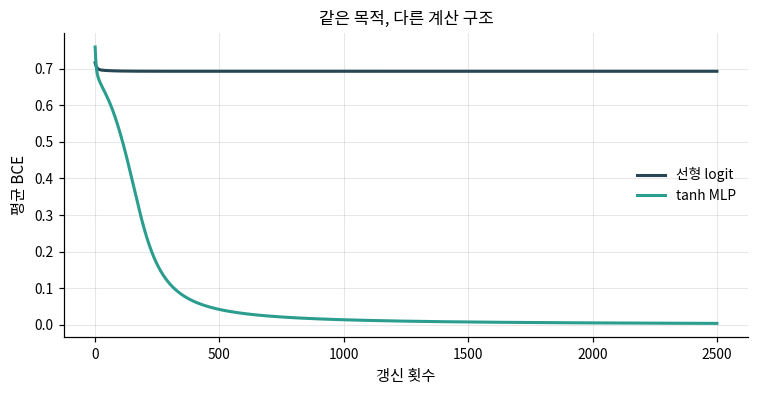

In [31]:
plot_training({"선형 logit": linear_history["train_bce"], "tanh MLP": mlp_history["train_bce"]})

🔍 **확인** · 선형 모델의 손실은 이 대칭적인 네 점에서 약 $\log2$로 수렴했습니다. 분리가 불가능하다는 근거는 앞의 네 부등식이며, 이 학습 결과는 그 한 사례입니다.
MLP는 같은 BCE를 사용하면서도 은닉 표현을 바꿀 수 있습니다. 손실과 모델 구조가 담당하는 역할을 구분해 볼 수 있습니다.

📎 격자 그림에서는 00처럼 `meshgrid → ravel → column_stack`으로 점을 만듭니다.
`xx`, `yy`는 `(100,100)`, `grid`는 `(10000,2)`, 예측 확률은 `(10000,1)`입니다. 그림용으로 다시 `(100,100)`으로 바꿉니다.

> **코드**
>
> - `grid_caches[0][1]`: 첫 층의 활성화 전 값 Z `(10000, 4)`. 활성화를 거친 뒤 `reshape(*xx.shape, 4)`로 `(100, 100, 4)`를 만듭니다. 별표는 `(100, 100)`을 두 인자로 풀어 넣는 것입니다.

In [32]:
# 쓰는 것: corners (📎 데이터 셀) · mlp_model (앞 학습 셀) · mlp_forward, activation (3·4절) · sigmoid (3절)
xx, yy = np.meshgrid(np.linspace(-0.4, 1.4, 100), np.linspace(-0.4, 1.4, 100))   # (100, 100) 둘: 격자의 x0, x1 좌표
grid = np.column_stack([xx.ravel(), yy.ravel()])                # (10000, 2): 격자점 하나가 입력 하나
grid_logits, grid_caches = mlp_forward(grid, mlp_model)         # (10000, 1): 학습한 MLP의 logit
grid_probability = sigmoid(grid_logits).reshape(xx.shape)      # (100, 100): 그림용으로 격자 모양으로 되돌림
hidden_grid = activation(grid_caches[0][1]).reshape(*xx.shape, 4)   # (100, 100, 4): 은닉 유닛 4개의 활성

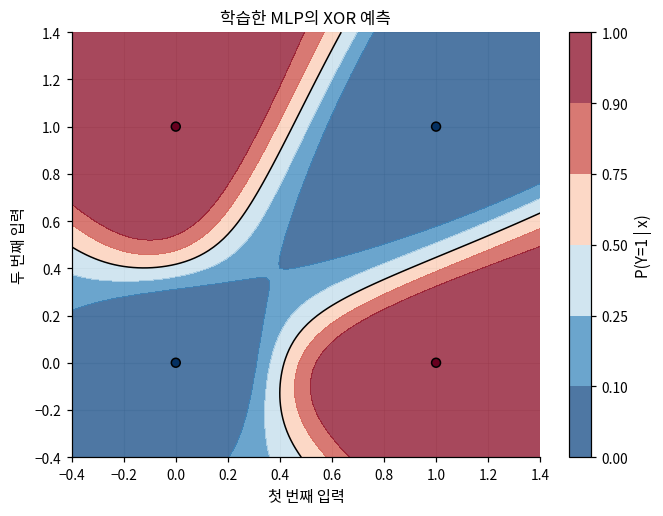

In [33]:
plot_regions(xx, yy, grid_probability, corners, Y_xor, "학습한 MLP의 XOR 예측")

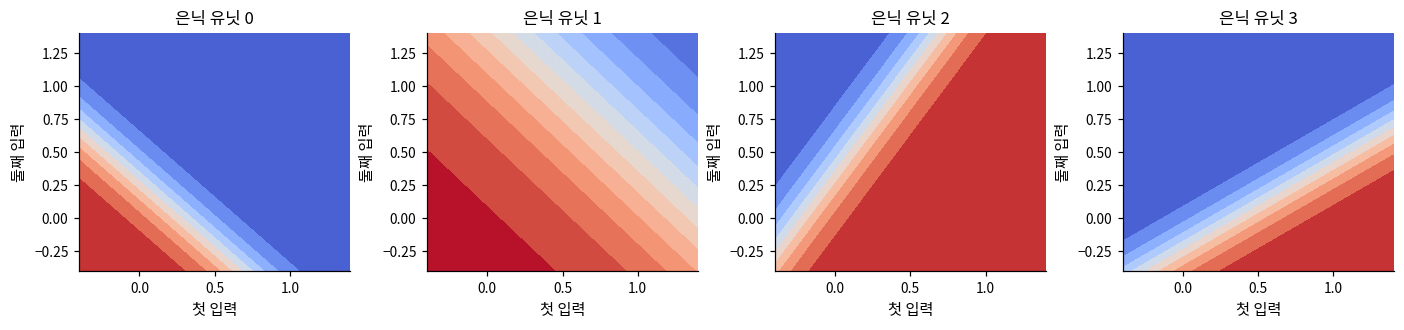

In [34]:
plot_hidden_maps(xx, yy, hidden_grid)

🔍 **확인** · 은닉 유닛마다 입력의 다른 부분에서 값이 달라지고, 마지막 선형층이 이 네 값을 조합해 logit을 만듭니다.
격자의 색은 네 학습점 사이와 바깥에서 **현재 모델이 하는 예측**입니다. 그 영역의 정답을 검증한 그림은 아닙니다.

### 🔍 MNIST에서는 은닉 유닛이 무엇을 배우나

같은 `fit_mlp`로 `[784, 32, 1]`을 5,000장에서 300스텝 학습시킵니다. 학습된 $W_1$의 열 하나가 은닉 유닛 하나의 가중치이고, 28×28로 접으면 "그 유닛이 보는 획"입니다.
초기 난수가 그대로 남아 있어 잡음처럼 보이므로, 학습으로 **바뀐 부분** $W_1-W_1^{(0)}$만 그립니다.

> **코드** · `np.argsort(-np.abs(w))[:8]`: 절댓값이 큰 순서로 정렬한 번호 중 앞 8개. `argsort`는 작은 순서이므로 음수를 붙여 큰 순서로 만듭니다.

In [35]:
# 쓰는 것: mnist_X, mnist_T, mnist_Xe, mnist_Te (📎 데이터 셀) · init_mlp, mlp_forward (4절) · fit_mlp (7절)
mnist_init = init_mlp([784, 32, 1], seed=0)
mnist_model, mnist_history = fit_mlp(mnist_X, mnist_T, mnist_init, steps=300, learning_rate=0.5)   # 5,000장으로 300스텝
mnist_logits, _ = mlp_forward(mnist_X, mnist_model)
mnist_train_accuracy = np.mean((mnist_logits >= 0) == mnist_T)             # 학습 데이터에서의 정확도
example_logits, _ = mlp_forward(mnist_Xe, mnist_model)                     # (10, 1): 예시 10장의 logit
assert mnist_history["train_bce"][-1] < 0.1, "300스텝 뒤 BCE가 0.1 아래여야 합니다"
assert np.mean((example_logits >= 0) == mnist_Te) == 1.0, "예시 10장은 모두 맞혀야 합니다"
top_units = np.argsort(-np.abs(mnist_model[1]["W"].ravel()))[:8]         # 출력 가중치 W2가 큰 은닉 유닛 8개의 번호
learned_change = mnist_model[0]["W"] - mnist_init[0]["W"]                  # (784, 32): 학습으로 바뀐 부분 (초기 난수를 뺌)
unit_images = [learned_change[:, j].reshape(28, 28) for j in top_units]    # 열 j를 28×28로 접음
unit_titles = [(f"$h_{{{j}}}$", f"$W_2={mnist_model[1]['W'][j, 0]:+.2f}$") for j in top_units]   # 그림 제목: 유닛 번호와 출력 가중치
print(f"BCE {mnist_history['train_bce'][0]:.3f} → {mnist_history['train_bce'][-1]:.3f} · 학습 정확도 {mnist_train_accuracy:.1%} · 예시 10장 판정",
      (example_logits.ravel() >= 0).astype(int))

BCE 0.770 → 0.036 · 학습 정확도 98.9% · 예시 10장 판정 [0 0 0 0 0 0 0 1 0 0]


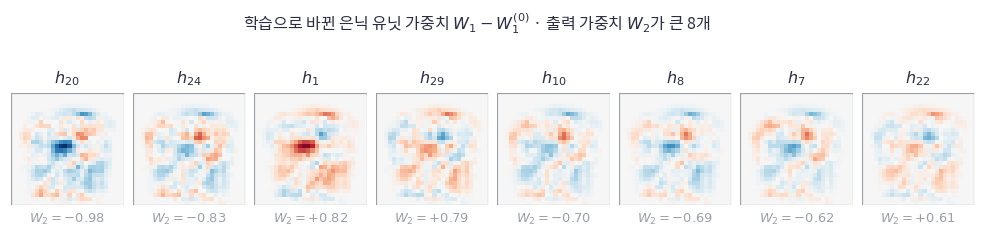

In [36]:
plot_hidden_templates(unit_images, unit_titles, "학습으로 바뀐 은닉 유닛 가중치 $W_1 - W_1^{(0)}$ · 출력 가중치 $W_2$가 큰 8개")

🔍 **확인** · 00번의 템플릿은 "7의 평균 모양" 하나였지만, 은닉 유닛들은 저마다 다른 획 조합을 봅니다. 7의 가로획을 보는 유닛, 세로획이나 다른 숫자의 곡선을 보는 유닛이 나뉩니다.
$W_2$가 양수인 유닛은 켜지면 "7이다"에 표를 주고, 음수인 유닛은 "7이 아니다"에 표를 줍니다. 마지막 층은 이 표들을 더해 logit을 만듭니다.
XOR에서 은닉 유닛 네 개가 입력을 새 좌표로 옮긴 것과 같은 일이 784차원에서 일어난 것입니다.

## 🔍 8. 새 데이터에서 확인하기: 분할과 L2

> **용어**
>
> - **학습·검증 분할**: 데이터를 둘로 나누어, 검증 데이터는 파라미터 갱신에 쓰지 않고 성능 측정에만 쓰는 것.
> - **일반화(generalization)**: 학습에 쓰지 않은 새 데이터에서도 잘 맞는 것.
> - **L2 정규화**: 가중치 제곱합에 페널티를 주어 가중치가 커지는 것을 막는 항. 목적에 더하고 미분에는 $\lambda W$를 더합니다.

학습에 사용하지 않은 표본의 BCE를 따로 계산합니다. 예제는 네 모서리 주변에 잡음을 더한 작은 XOR 분포입니다.
학습·검증 데이터를 서로 다른 난수로 생성하며, 검증 데이터는 파라미터 업데이트에 넣지 않습니다.

L2를 적용하면 목적은 다음과 같습니다.

$$J=\underbrace{\frac1N\sum_n\ell_n}_{\text{평균 BCE}}+
\underbrace{\frac\lambda2\sum_\ell\|W_\ell\|_F^2}_{\text{가중치 제곱합 페널티}}.$$

$\|W\|_F^2=\sum_{d,k}W_{dk}^2$이며 미분에는 $\lambda W$를 더합니다. 여기서는 편향에 페널티를 주지 않습니다.
이미 평균낸 BCE에 페널티를 더하므로 **페널티를 N으로 다시 나누지 않습니다.** 다른 정의를 쓰면 $\lambda$의 의미도 달라집니다.
그림에서는 두 모델을 공정하게 읽도록 페널티를 제외한 BCE를 비교하고, 업데이트는 각각 정의한 목적을 사용합니다.

> **코드**
>
> - `np.repeat(corners, n, axis=0)`: 행마다 n번씩 되풀이해 `(4n, 2)`. 네 모서리 각각에 표본 n개를 둡니다.
> - `rng.permutation(len(X))`: 0…N−1을 무작위 순서로. `X[order]`로 표본을 섞습니다.
> - `for strength, (_, history) in regularization_results.items()`: 사전의 (키, 값)을 돌며 값 쌍 중 쓰지 않는 모델은 `_`로 버립니다.

In [37]:
def sample_noisy_xor(samples_per_corner, seed):
    """네 모서리 주변에 잡음(표준편차 0.22)을 더한 XOR 데이터. → (X: (4n, 2), Y: (4n, 1)), 순서는 섞음."""
    # 쓰는 것: corners, Y_xor (📎 데이터 셀)
    rng = np.random.default_rng(seed)
    X = np.repeat(corners, samples_per_corner, axis=0)          # (4n, 2): 모서리마다 n개
    X = X + rng.normal(0, 0.22, size=X.shape)                   # 잡음을 더함
    Y = np.repeat(Y_xor, samples_per_corner, axis=0)            # (4n, 1): 같은 순서의 라벨
    order = rng.permutation(len(X))
    return X[order], Y[order]

In [38]:
# 쓰는 것: check_X, check_Y, check_parameters, check_mlp_gradients (6절) · init_mlp (4절) · fit_mlp (7절)
regularized_errors = check_mlp_gradients(check_X, check_Y, check_parameters, l2=0.03)   # L2 항의 미분 λW도 중심차분과 대조
train_X, train_Y = sample_noisy_xor(12, seed=10)             # (48, 2): 학습용
val_X, val_Y = sample_noisy_xor(80, seed=11)                 # (320, 2): 검증용. 다른 시드
shared_initial = init_mlp([2, 8, 1], seed=5)                 # 두 실험이 같은 시작점에서 출발
regularization_results = {}
for strength in (0.0, 0.01):                                 # λ = 0 (페널티 없음)과 0.01
    model, history = fit_mlp(train_X, train_Y, shared_initial, steps=1800,
                             learning_rate=0.15, l2=strength, validation=(val_X, val_Y))
    regularization_results[strength] = (model, history)
    print(f"λ={strength}: train BCE={history['train_bce'][-1]:.4f}, "
          f"validation BCE={history['validation_bce'][-1]:.4f}")
np.testing.assert_allclose(shared_initial[0]["b"], 0)        # 검산: fit_mlp가 복사해서 학습하므로 공유 시작점은 그대로

[gradcheck] W1
  ok   dx  rel_err = 1.437e-10
[gradcheck] b1
  ok   dx  rel_err = 1.947e-10
[gradcheck] W2
  ok   dx  rel_err = 2.404e-10
[gradcheck] b2
  ok   dx  rel_err = 2.829e-10
[gradcheck] W3
  ok   dx  rel_err = 2.303e-10
[gradcheck] b3
  ok   dx  rel_err = 4.570e-10
[gradcheck] X
  ok   dx  rel_err = 5.531e-10
λ=0.0: train BCE=0.0166, validation BCE=0.0985


λ=0.01: train BCE=0.1399, validation BCE=0.1908


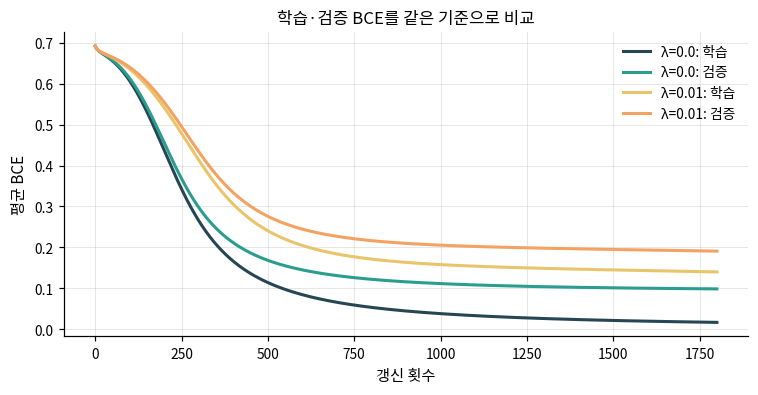

In [39]:
comparison = {}                                              # 그림용: 이름 → 손실 곡선
for strength, (_, history) in regularization_results.items():
    comparison[f"λ={strength}: 학습"] = history["train_bce"]
    comparison[f"λ={strength}: 검증"] = history["validation_bce"]
plot_training(comparison, title="학습·검증 BCE를 같은 기준으로 비교")

🔍 **확인** · L2가 검증 성능을 항상 높이는 것은 아닙니다. 위 숫자는 이 데이터·시드·학습 설정에서의 관측값입니다.
검증 결과로 설정을 고르기 시작하면 그 검증셋도 선택 과정에 사용됩니다. 최종 일반화 성능을 보고하려면 선택에 사용하지 않은 테스트셋을 따로 둡니다. 여기서는 분할과 목적의 차이를 확인하는 실험까지만 합니다.

## ✏️ 9. 직접 채워서 확인합니다

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.**
`raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요.
아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

### 연습 A · 활성화 미분 바꾸기 (3절)

Leaky ReLU는 $f(z)=z$ ($z>0$), $f(z)=\alpha z$ ($z<0$)입니다. $\alpha=0.1$일 때 원소별 도함수 한 줄을 채우세요.

In [40]:
def exercise_leaky_derivative(z, alpha=0.1):
    """연습 A: Leaky ReLU의 원소별 도함수. z: 어떤 모양 → 같은 모양 (z > 0이면 1, 아니면 alpha)."""
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: z > 0 이면 1, 아니면 alpha 인 배열 (모양 z와 같음)
    ### 힌트: np.where(조건, 참일 때 값, 거짓일 때 값)
    raise NotImplementedError
    return derivative

In [41]:
def check_leaky_derivative(candidate):
    """손계산 네 점과 중심차분(check_function)으로 검사합니다. 통과하면 메시지를 출력합니다."""
    z = np.array([-2., -0.3, 0.2, 1.5])
    np.testing.assert_allclose(candidate(z), [0.1, 0.1, 1., 1.])     # 검산: 음수 자리 0.1, 양수 자리 1

    def leaky_forward(v):
        """검사기용: Leaky ReLU 출력 (v > 0이면 v, 아니면 0.1v)."""
        return np.where(v > 0, v, 0.1*v)

    def leaky_backward(dout, v):
        """검사기용: 상류 기울기 × 후보 도함수."""
        return dout * candidate(v)

    check_function(leaky_forward, leaky_backward, z, verbose=True, name="Leaky ReLU")
    print("직접 만든 도함수가 손계산·중심차분과 일치합니다.")

run_check(check_leaky_derivative, exercise_leaky_derivative, hint="derivative = np.where(z > 0, 1.0, alpha)")

☐ exercise_leaky_derivative: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: derivative = np.where(z > 0, 1.0, alpha)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
derivative = np.where(z > 0, 1.0, alpha)
```

</details>

### ✏️ 연습 B · 은닉층 하나의 forward (4절)

입력 `A_prev`, 가중치 `W`, 편향 `b`에서 활성화 전 값 `Z`와 tanh 활성 `A`를 만드는 두 줄을 채우세요.

In [42]:
def exercise_tanh_layer(A_prev, W, b):
    """연습 B: 은닉층 하나의 forward. A_prev: (N, d_in), W: (d_in, d_out), b: (d_out,) → (A: (N, d_out), Z: (N, d_out))."""
    assert A_prev.shape[1] == W.shape[0], "A_prev의 열 수와 W의 행 수가 같아야 합니다"
    assert b.shape == (W.shape[1],), "b는 (d_out,)이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: Z = 선형 계산, A = tanh(Z)
    ### 힌트: 4절 mlp_forward 반복문 안의 두 줄입니다.
    raise NotImplementedError
    return A, Z

In [43]:
def check_tanh_layer(candidate):
    """4절의 손계산 예제와 본문 mlp_forward의 첫 층 캐시로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: small_X, small_parameters, mlp_forward (4절)
    A, Z = candidate(np.array([[1., 2.]]), np.array([[1., -1.], [0.5, 2.]]), np.array([0.1, -0.2]))
    np.testing.assert_allclose(Z, [[2.1, 2.8]])                       # 검산: 4절 손계산 Z
    np.testing.assert_allclose(A, np.tanh([[2.1, 2.8]]))              # 검산: 그 tanh
    logits_ref, caches_ref = mlp_forward(small_X, small_parameters)
    A1, Z1 = candidate(small_X, small_parameters[0]["W"], small_parameters[0]["b"])
    np.testing.assert_allclose(Z1, caches_ref[0][1])                  # 검산: 본문 첫 층의 Z
    np.testing.assert_allclose(A1, caches_ref[1][0])                  # 검산: 본문 둘째 층의 입력 = 첫 층의 A
    print("은닉층 forward: 4절 손계산·본문 함수와 일치합니다.")

run_check(check_tanh_layer, exercise_tanh_layer, hint="Z = A_prev @ W + b; A = np.tanh(Z)")

☐ exercise_tanh_layer: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: Z = A_prev @ W + b; A = np.tanh(Z)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
Z = A_prev @ W + b
A = np.tanh(Z)
```

</details>

### ✏️ 연습 C · 층 하나의 backward (5절)

상류 기울기 `dZ`와 캐시에서 `dW`, `db`, `dA_prev`를 만듭니다. `db`는 미리 써 두었으니 행렬곱 두 줄을 채우세요.

In [44]:
def exercise_layer_backward(dZ, A_prev, W):
    """연습 C: 층 하나의 backward. dZ: (N, d_out), A_prev: (N, d_in), W: (d_in, d_out) → (dA_prev: (N, d_in), dW: (d_in, d_out), db: (d_out,))."""
    db = dZ.sum(axis=0)                # (d_out,): 미리 써 둔 줄. 샘플 축의 합
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: dW (모양 W와 같음), dA_prev (모양 A_prev와 같음)
    ### 힌트: 5절의 세 식 중 A_{ℓ-1}^T D_ℓ 과 D_ℓ W_ℓ^T 입니다.
    raise NotImplementedError
    return dA_prev, dW, db

In [45]:
def check_layer_backward(candidate):
    """샘플 2개 × (2 → 1) 손계산 예제로 검사합니다. 통과하면 메시지를 출력합니다."""
    A_prev = np.array([[1., 2.], [-1., 1.]])         # (2, 2)
    W = np.array([[2.], [3.]])                       # (2, 1)
    dZ = np.array([[0.2], [-0.4]])                   # (2, 1)
    dA_prev, dW, db = candidate(dZ, A_prev, W)
    np.testing.assert_allclose(dA_prev, [[0.4, 0.6], [-0.8, -1.2]])   # 검산: dZ @ Wᵀ = 행마다 dZ × [2, 3]
    np.testing.assert_allclose(dW, [[0.6], [0.]], atol=1e-15)          # 검산: A_prevᵀ @ dZ = [1·0.2 − 1·(−0.4), 2·0.2 + 1·(−0.4)]
    np.testing.assert_allclose(db, [-0.2])                             # 검산: 0.2 − 0.4
    print("층 하나의 backward: 손계산과 일치합니다.")

run_check(check_layer_backward, exercise_layer_backward, hint="dW = A_prev.T @ dZ; dA_prev = dZ @ W.T")

☐ exercise_layer_backward: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dW = A_prev.T @ dZ; dA_prev = dZ @ W.T


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dW = A_prev.T @ dZ
dA_prev = dZ @ W.T
```

</details>

### 🔍 완성 예제 · 은닉층의 너비 바꾸기

`[2,3,2,1]`을 `[2,5,3,1]`로 바꾸면 W와 b의 shape만 달라지고 forward·backward의 식은 같습니다. 학습 전에 기울기를 검산합니다. 다른 너비로 바꿔 보세요.

In [46]:
# 쓰는 것: check_X, check_Y, check_mlp_gradients (6절) · init_mlp (4절)
changed_parameters = init_mlp([2, 5, 3, 1], seed=23)                       # 너비를 바꾼 구조
expected_shapes = [((2,5), (5,)), ((5,3), (3,)), ((3,1), (1,))]            # 층마다 기대하는 (W 모양, b 모양)
for layer, (w_shape, b_shape) in zip(changed_parameters, expected_shapes):
    assert layer["W"].shape == w_shape, f"W 모양은 {w_shape}여야 합니다"
    assert layer["b"].shape == b_shape, f"b 모양은 {b_shape}여야 합니다"
changed_errors = check_mlp_gradients(check_X, check_Y, changed_parameters)   # 식은 그대로이므로 같은 검산이 통과해야 함
print("구조 변형의 최대 상대오차", max(changed_errors.values()))

[gradcheck] W1
  ok   dx  rel_err = 5.696e-10
[gradcheck] b1
  ok   dx  rel_err = 9.753e-10
[gradcheck] W2
  ok   dx  rel_err = 4.583e-10
[gradcheck] b2
  ok   dx  rel_err = 3.263e-10
[gradcheck] W3
  ok   dx  rel_err = 1.482e-09
[gradcheck] b3
  ok   dx  rel_err = 4.005e-10
[gradcheck] X
  ok   dx  rel_err = 2.564e-09
구조 변형의 최대 상대오차 2.5641789882291924e-09


### ✏️ 준비도 질문 · 다음으로 가기 전, 네 가지를 따로 확인합니다

🔑 표시가 붙은 절의 내용만으로 답할 수 있어야 합니다.

- **설명:** XOR의 네 부등식으로 선형 판정의 한계를 보이고 은닉층이 바꾸는 것을 말할 수 있나요? → 2·3절
- **수식:** 한 은닉층을 거꾸로 통과할 때 행렬곱과 원소별 곱을 구분해 쓸 수 있나요? → 5절
- **구현:** 캐시에 무엇을 남길지 정하고, 모든 W·b·X의 미분을 검산했나요? → 4–6절
- **변형:** 층 너비·깊이·활성화·L2를 바꾸면 어느 식과 어느 검산이 바뀌나요? → 8·9절

다음은 [04 · optimizer의 계산](04_optimizers.ipynb)입니다. 검산한 기울기를 받은 뒤 파라미터를 갱신하는 방식을 바꿉니다.

📎 참고: [D2L MLP](https://d2l.ai/chapter_multilayer-perceptrons/mlp.html), [Glorot·Bengio의 초기화 논문](https://proceedings.mlr.press/v9/glorot10a.html). 그림·기울기·학습 결과는 본문에서 계산합니다.